**© Copyright AIDENTIFY. All rights reserved.**

본 자료는 **멀티캠퍼스 LLM 파인튜닝 과정** 수강생을 위해 제작되었으며, 강의 목적으로만 사용 가능합니다.  
무단 복제, 배포, 상업적 이용을 금지합니다.

---

# Session 26b: Rejection Sampling + SFT 실습

## 🎯 Rejection Sampling이란?

**Rejection Sampling (Best-of-N Sampling)**은 강화학습 없이도 모델 성능을 향상시키는 강력한 기법입니다.

### 핵심 아이디어
```
1. 같은 프롬프트에 대해 모델이 N개의 응답을 생성
2. 보상 모델(또는 LLM Judge)로 각 응답에 점수 부여
3. 가장 높은 점수의 응답만 선택
4. 선택된 고품질 응답으로 SFT 학습!
```

### 왜 Rejection Sampling인가?

| 방법 | 장점 | 단점 |
|------|------|------|
| 일반 SFT | 간단함 | 데이터 품질에 의존 |
| **Rejection Sampling + SFT** | **자체 모델에서 고품질 데이터 추출** | 생성 비용 (N배) |
| DPO/PPO | 직접 선호도 학습 | 복잡한 설정 필요 |

### DeepSeek R1에서의 활용
DeepSeek R1 파이프라인에서도 **RS + SFT**가 핵심 단계입니다:
```
Cold Start → GRPO → Rejection Sampling + SFT → GRPO → Final RL
```

### 학습 목표
- ✅ Rejection Sampling의 개념과 원리 이해
- ✅ 모델에서 N개 응답 생성 (temperature sampling)
- ✅ LLM-as-a-Judge로 응답 품질 평가
- ✅ Best-of-N 선택으로 고품질 SFT 데이터 구축
- ✅ 선택된 데이터로 SFT 학습 및 성능 비교

### 실습 환경
- 모델: Qwen2.5-1.5B-Instruct (FP16)
- 평가: GPT-4o-mini (LLM Judge)
- GPU: RTX 4060 (8GB) 호환
- 예상 VRAM: ~4-5GB

## 1️⃣ 환경 설정 및 모델 로드

In [1]:
# 필수 라이브러리 임포트
import torch
import gc
import os
import json
import time
import random
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments
)
from peft import LoraConfig, get_peft_model, TaskType
from trl import SFTTrainer, SFTConfig
from datasets import Dataset
from openai import OpenAI

# OpenAI 클라이언트 (LLM Judge용)
client = OpenAI()

print("✅ 라이브러리 임포트 완료")

/home/ejkim/LLM_Advanced/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ejkim/LLM_Advanced/venv/lib/python3.12/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


✅ 라이브러리 임포트 완료


In [2]:
# GPU 메모리 모니터링 함수
def print_gpu_memory(tag=""):
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        total = torch.cuda.get_device_properties(0).total_memory / 1024**3
        print(f"[{tag}] GPU: {allocated:.1f}GB / {total:.1f}GB")


In [3]:
# 모델 설정
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
OUTPUT_DIR = "./output/rejection_sampling_sft"

# 토크나이저 로드
print("⏳ 토크나이저 로딩 중...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# 모델 로드 (FP16 - 양자화 없음)
print("⏳ 모델 로딩 중... (FP16)")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)
model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
model.enable_input_require_grads()

print(f"✅ 모델 로드 완료: {MODEL_NAME}")
print_gpu_memory("모델 로드 후")

⏳ 토크나이저 로딩 중...
⏳ 모델 로딩 중... (FP16)


`torch_dtype` is deprecated! Use `dtype` instead!


✅ 모델 로드 완료: Qwen/Qwen2.5-1.5B-Instruct
[모델 로드 후] GPU: 2.9GB / 23.5GB


## 2️⃣ 프롬프트 준비 및 N개 응답 생성

Rejection Sampling의 첫 번째 단계: **같은 프롬프트에 대해 여러 응답을 생성**합니다.

### 핵심 파라미터
- **N (생성 개수)**: 보통 4~16개. N이 클수록 좋은 응답 나올 확률 ↑, 하지만 비용도 ↑
- **temperature**: 0.7~1.0 권장. 너무 낮으면 다양성 ↓, 너무 높으면 품질 ↓
- **top_p**: 0.9~0.95로 약간의 다양성 확보

In [4]:
# 학습용 프롬프트 준비
prompts = [
    "머신러닝과 딥러닝의 차이점을 설명하세요.",
    "좋은 프롬프트를 작성하는 방법을 알려주세요.",
    "Python에서 리스트와 튜플의 차이점은 무엇인가요?",
    "트랜스포머 모델의 어텐션 메커니즘을 설명하세요.",
    "오버피팅을 방지하는 방법들을 나열하세요.",
    "REST API와 GraphQL의 차이를 비교하세요.",
    "Git에서 rebase와 merge의 차이를 설명하세요.",
    "데이터 정규화가 왜 중요한지 설명하세요.",
    "LoRA 파인튜닝의 장점을 설명하세요.",
    "RAG(Retrieval-Augmented Generation)의 원리를 설명하세요.",
    "경사 하강법(Gradient Descent)의 원리를 설명하세요.",
    "LLM의 환각(Hallucination) 문제와 해결 방법을 설명하세요.",
    "배치 정규화(Batch Normalization)의 역할을 설명하세요.",
    "Docker와 가상머신의 차이를 설명하세요.",
    "학습률(Learning Rate)이 모델 학습에 미치는 영향을 설명하세요.",
]

print(f"✅ 프롬프트 준비 완료: {len(prompts)}개")
for i, p in enumerate(prompts[:5]):
    print(f"  {i+1}. {p}")
print(f"  ... (총 {len(prompts)}개)")


✅ 프롬프트 준비 완료: 15개
  1. 머신러닝과 딥러닝의 차이점을 설명하세요.
  2. 좋은 프롬프트를 작성하는 방법을 알려주세요.
  3. Python에서 리스트와 튜플의 차이점은 무엇인가요?
  4. 트랜스포머 모델의 어텐션 메커니즘을 설명하세요.
  5. 오버피팅을 방지하는 방법들을 나열하세요.
  ... (총 15개)


In [5]:
# N개 응답 생성 함수
def generate_n_responses(model, tokenizer, prompt, n=8, max_new_tokens=256,
                         temperature=0.8, top_p=0.9):
    """같은 프롬프트에 대해 N개의 다양한 응답을 생성"""
    messages = [
        {"role": "system", "content": "당신은 유용한 AI 어시스턴트입니다. 질문에 정확하고 도움이 되는 답변을 하세요."},
        {"role": "user", "content": prompt}
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    
    responses = []
    for i in range(n):
        with torch.no_grad():
            output = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                top_p=top_p,
                do_sample=True,
                pad_token_id=tokenizer.pad_token_id,
            )
        response = tokenizer.decode(output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
        responses.append(response.strip())
    
    return responses

# 테스트: 첫 번째 프롬프트로 응답 다양성 확인
print("📊 응답 다양성 테스트 (첫 번째 프롬프트)")
print("="*60)
print(f"프롬프트: {prompts[0]}")
print("="*60)

test_responses = generate_n_responses(model, tokenizer, prompts[0], n=4)
for i, resp in enumerate(test_responses):
    print(f"\n🔹 응답 {i+1}:")
    print(f"  {resp[:200]}...")
    print(f"  (길이: {len(resp)}자)")


📊 응답 다양성 테스트 (첫 번째 프롬프트)
프롬프트: 머신러닝과 딥러닝의 차이점을 설명하세요.

🔹 응답 1:
  머신러닝(Machine Learning)과 딥러닝(Deep Learning)은 모두 AI 분야에서 중요한 기술이며, 둘 사이에는 많은 차이점이 있습니다.

1. **정의와 범위:**
   - **머신러닝**은 데이터를 통해 모델을 학습시키고 예측할 수 있는 알고리즘과 도구들을 의미합니다.
   - **딥러닝**은 머신러닝의 한 부문으로서, 이론적으로 더 복...
  (길이: 448자)

🔹 응답 2:
  머신러닝과 딥러닝 모두 인공지능과 관련된 주요 기술 중 하나로, 이 두 개념은 매우 비슷하지만 구체적으로 다를 수 있습니다.

1. 머신러닝:

- 모든 데이터와 알고리즘을 활용하여 학습하는 방법입니다.
- 개발자는 모델을 학습시키고 예측 결과를 얻을 때 사용합니다.

2. 딥러닝:

- 고차원 데이터나 복잡한 문제에 강한 방식으로 설계되었습니다.
- 여러...
  (길이: 400자)

🔹 응답 3:
  머신러닝과 딥러닝 모두 인공지능에서 중요한 개념 중 하나지만, 두 가지 방법론은 매우 다른 방식으로 서로를 수행합니다.

1. **머신러닝(Machine Learning)**:
   - 머신러닝은 데이터를 학습하고 이를 기반으로 예측 또는 판단하는 알고리즘을 개발하는데 사용되는 기술로, 이러한 알고리즘이 자체적으로 모델링할 수 있는 특징이 없습니다.
   ...
  (길이: 450자)

🔹 응답 4:
  머신러닝(Machine Learning)과 딥러닝(Depth Learning)은 컴퓨터가 데이터를 분석하고 스스로 학습하는 기술로, 모두 AI(Automatic Intelligence)에서 중요한 부분을 차지합니다.

1. **모델 구조**: 
   - **머신러닝**은 일반적으로 회귀나 분류 모델을 사용하며, 이러한 모델들은 학습 시에는 특정 알고리즘(예...
  (길이: 460자)


In [6]:
# 전체 프롬프트에 대해 N개 응답 생성 (또는 기존 데이터 로드)
N = 8  # 프롬프트당 생성할 응답 수
CANDIDATES_PATH = os.path.join(OUTPUT_DIR, "all_candidates.json")

if os.path.exists(CANDIDATES_PATH):
    print(f"💾 기존 응답 데이터 로드: {CANDIDATES_PATH}")
    with open(CANDIDATES_PATH, "r", encoding="utf-8") as f:
        all_candidates = json.load(f)
    print(f"   📄 {len(all_candidates)}개 프롬프트 x {len(all_candidates[0]['responses'])}개 응답")
else:
    print(f"🚀 전체 {len(prompts)}개 프롬프트 x {N}개 응답 = {len(prompts) * N}개 생성 시작!")
    print("="*60)
    all_candidates = []
    for idx, prompt in enumerate(prompts):
        print(f"⏳ [{idx+1}/{len(prompts)}] {prompt[:40]}...")
        responses = generate_n_responses(model, tokenizer, prompt, n=N)
        all_candidates.append({"prompt": prompt, "responses": responses})
        print(f"   ✅ {len(responses)}개 응답 생성 완료")

    # 저장
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    with open(CANDIDATES_PATH, "w", encoding="utf-8") as f:
        json.dump(all_candidates, f, ensure_ascii=False, indent=2)
    print(f"\n💾 응답 데이터 저장: {CANDIDATES_PATH}")

print("="*60)
print(f"✅ 전체 응답: {sum(len(c['responses']) for c in all_candidates)}개")


## 3️⃣ LLM-as-a-Judge로 응답 평가 (GPT-4o-mini)

Rejection Sampling의 두 번째 단계: **각 응답에 점수를 매깁니다.**

### 평가 기준
- **정확성** (1-5): 내용이 사실적이고 올바른가?
- **완성도** (1-5): 충분히 자세하고 구체적인가?
- **명확성** (1-5): 이해하기 쉽고 잘 구조화되어 있는가?
- **종합 점수**: 3개 점수의 평균

### 왜 GPT-4o-mini를 Judge로 사용하나?
- 비용: 1건당 ~$0.001 (매우 저렴)
- 속도: 빠른 응답
- 품질: 1.5B 모델 응답 평가에는 충분한 수준

In [7]:
# LLM Judge 함수 (GPT-4o-mini)
def score_response(prompt, response, model_name="gpt-4o-mini"):
    """GPT-4o-mini로 응답 품질을 1-5점으로 평가"""
    judge_prompt = f"""당신은 AI 응답 품질을 평가하는 전문 평가자입니다.
아래의 질문과 응답을 읽고, 3가지 기준으로 1-5점을 매겨주세요.

## 질문
{prompt}

## 응답
{response}

## 평가 기준
1. 정확성 (1-5): 내용이 사실적이고 올바른가?
2. 완성도 (1-5): 충분히 자세하고 구체적인가?
3. 명확성 (1-5): 이해하기 쉽고 잘 구조화되어 있는가?

반드시 아래 JSON 형식으로만 답변하세요:
{{"accuracy": 점수, "completeness": 점수, "clarity": 점수, "reason": "한 줄 평가 이유"}}"""

    try:
        resp = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": judge_prompt}],
            temperature=0.1,
            response_format={"type": "json_object"},
        )
        result = json.loads(resp.choices[0].message.content)
        avg_score = (result["accuracy"] + result["completeness"] + result["clarity"]) / 3
        result["avg_score"] = round(avg_score, 2)
        return result
    except Exception as e:
        print(f"  ⚠️ 평가 실패: {e}")
        return {"accuracy": 3, "completeness": 3, "clarity": 3, "avg_score": 3.0, "reason": "평가 실패"}

# 테스트
print("📊 LLM Judge 테스트")
print("="*60)
test_score = score_response(prompts[0], test_responses[0])
print(f"프롬프트: {prompts[0]}")
print(f"응답: {test_responses[0][:100]}...")
print(f"평가: {json.dumps(test_score, ensure_ascii=False, indent=2)}")


📊 LLM Judge 테스트
프롬프트: 머신러닝과 딥러닝의 차이점을 설명하세요.
응답: 머신러닝(Machine Learning)과 딥러닝(Deep Learning)은 모두 AI 분야에서 중요한 기술이며, 둘 사이에는 많은 차이점이 있습니다.

1. **정의와 범위:*...
평가: {
  "accuracy": 4,
  "completeness": 3,
  "clarity": 4,
  "reason": "응답은 머신러닝과 딥러닝의 차이를 잘 설명하고 있으나, 학습 과정에 대한 설명이 미완성이다.",
  "avg_score": 3.67
}


In [8]:
# 전체 응답 평가 (또는 기존 평가 데이터 로드)
SCORED_PATH = os.path.join(OUTPUT_DIR, "scored_candidates.json")

if os.path.exists(SCORED_PATH):
    print(f"💾 기존 평가 데이터 로드: {SCORED_PATH}")
    with open(SCORED_PATH, "r", encoding="utf-8") as f:
        scored_candidates = json.load(f)
    print(f"   📄 {len(scored_candidates)}개 프롬프트 평가 완료")
else:
    print("🚀 전체 응답 LLM Judge 평가 시작!")
    print("="*60)
    scored_candidates = []
    for idx, candidate in enumerate(all_candidates):
        prompt = candidate["prompt"]
        print(f"\n⏳ [{idx+1}/{len(all_candidates)}] {prompt[:40]}...")
        scored_responses = []
        for j, response in enumerate(candidate["responses"]):
            score = score_response(prompt, response)
            scored_responses.append({"response": response, "score": score})
            print(f"   응답 {j+1}: {score['avg_score']:.1f}점 ({score.get('reason', '')[:30]})")
        scored_responses.sort(key=lambda x: x["score"]["avg_score"], reverse=True)
        scored_candidates.append({
            "prompt": prompt,
            "scored_responses": scored_responses,
            "best_score": scored_responses[0]["score"]["avg_score"],
            "worst_score": scored_responses[-1]["score"]["avg_score"],
        })
        print(f"   📊 최고: {scored_responses[0]['score']['avg_score']:.1f}점 / 최저: {scored_responses[-1]['score']['avg_score']:.1f}점")

    # 저장
    with open(SCORED_PATH, "w", encoding="utf-8") as f:
        json.dump(scored_candidates, f, ensure_ascii=False, indent=2)
    print(f"\n💾 평가 데이터 저장: {SCORED_PATH}")

print("\n" + "="*60)
print("✅ 전체 평가 완료!")


## 4️⃣ Best-of-N 선택 — 고품질 SFT 데이터 구축

핵심 단계: **각 프롬프트에서 가장 높은 점수의 응답만 선택**합니다.

### 선택 전략
- **Best-of-N**: 최고 점수 1개만 선택 (가장 기본)
- **Top-K**: 상위 K개 선택 (데이터 양 확보)
- **Threshold**: 특정 점수 이상만 선택 (품질 보장)

이번 실습에서는 **Best-of-N (최고 1개)** + **Threshold (4.0점 이상 추가 선택)**을 결합합니다.

In [9]:
# Best-of-N 선택 + Threshold 필터링
SCORE_THRESHOLD = 4.0  # 이 점수 이상의 응답도 추가 선택

selected_data = []
rejected_data = []  # 비교용 (최저 점수 응답)

print("📊 Best-of-N 선택 결과")
print("="*60)

for candidate in scored_candidates:
    prompt = candidate["prompt"]
    responses = candidate["scored_responses"]
    
    # Best (최고 점수)
    best = responses[0]
    selected_data.append({
        "prompt": prompt,
        "response": best["response"],
        "score": best["score"]["avg_score"],
        "selection": "best-of-N",
    })
    
    # Threshold (추가 선택: best 제외, 4.0 이상)
    for resp in responses[1:]:
        if resp["score"]["avg_score"] >= SCORE_THRESHOLD:
            selected_data.append({
                "prompt": prompt,
                "response": resp["response"],
                "score": resp["score"]["avg_score"],
                "selection": "threshold",
            })
    
    # Worst (비교용)
    worst = responses[-1]
    rejected_data.append({
        "prompt": prompt,
        "response": worst["response"],
        "score": worst["score"]["avg_score"],
    })
    
    print(f"📌 {prompt[:40]}...")
    print(f"   Best: {best['score']['avg_score']:.1f}점 / Worst: {worst['score']['avg_score']:.1f}점 / 차이: {best['score']['avg_score'] - worst['score']['avg_score']:.1f}")

print("\n" + "="*60)
print(f"✅ 선택 완료!")
print(f"   📄 선택된 고품질 데이터: {len(selected_data)}건")
print(f"   📄 비교용 저품질 데이터: {len(rejected_data)}건")
print(f"   📊 평균 점수 (선택): {sum(d['score'] for d in selected_data)/len(selected_data):.2f}")
print(f"   📊 평균 점수 (탈락): {sum(d['score'] for d in rejected_data)/len(rejected_data):.2f}")


📊 Best-of-N 선택 결과
📌 머신러닝과 딥러닝의 차이점을 설명하세요....
   Best: 4.3점 / Worst: 3.3점 / 차이: 1.0
📌 좋은 프롬프트를 작성하는 방법을 알려주세요....
   Best: 5.0점 / Worst: 3.7점 / 차이: 1.3
📌 Python에서 리스트와 튜플의 차이점은 무엇인가요?...
   Best: 4.7점 / Worst: 3.3점 / 차이: 1.3
📌 트랜스포머 모델의 어텐션 메커니즘을 설명하세요....
   Best: 3.7점 / Worst: 2.7점 / 차이: 1.0
📌 오버피팅을 방지하는 방법들을 나열하세요....
   Best: 5.0점 / Worst: 3.7점 / 차이: 1.3
📌 REST API와 GraphQL의 차이를 비교하세요....
   Best: 3.7점 / Worst: 3.3점 / 차이: 0.3
📌 Git에서 rebase와 merge의 차이를 설명하세요....
   Best: 3.7점 / Worst: 3.3점 / 차이: 0.3
📌 데이터 정규화가 왜 중요한지 설명하세요....
   Best: 4.3점 / Worst: 3.7점 / 차이: 0.7
📌 LoRA 파인튜닝의 장점을 설명하세요....
   Best: 3.7점 / Worst: 3.3점 / 차이: 0.3
📌 RAG(Retrieval-Augmented Generation)의 원리를...
   Best: 3.7점 / Worst: 3.3점 / 차이: 0.3
📌 경사 하강법(Gradient Descent)의 원리를 설명하세요....
   Best: 4.3점 / Worst: 3.7점 / 차이: 0.7
📌 LLM의 환각(Hallucination) 문제와 해결 방법을 설명하세요....
   Best: 3.7점 / Worst: 2.7점 / 차이: 1.0
📌 배치 정규화(Batch Normalization)의 역할을 설명하세요....
   Best: 3.7점 / Worst: 3.7점 / 차이: 0.0
📌 Docker와 가상머신의 차이를 설명하세요....

📊 Score Distribution Analysis

🔹 All (120 responses):
   Mean: 3.70 / Max: 5.0 / Min: 2.7
   5.0~5.4: ██ (2)
   4.5~4.9: ███ (3)
   4.0~4.4: ███████████ (11)
   3.5~3.9: ███████████████████████████████████████████████████████████████████████████████████ (83)
   3.0~3.4: ███████████████████ (19)
   2.5~2.9: ██ (2)

🔹 Selected (25 responses):
   Mean: 4.15 / Max: 5.0 / Min: 3.7
   5.0~5.4: ██ (2)
   4.5~4.9: ███ (3)
   4.0~4.4: ███████████ (11)
   3.5~3.9: █████████ (9)

🔹 Rejected(worst) (15 responses):
   Mean: 3.36 / Max: 3.7 / Min: 2.7
   3.5~3.9: █████ (5)
   3.0~3.4: ████████ (8)
   2.5~2.9: ██ (2)


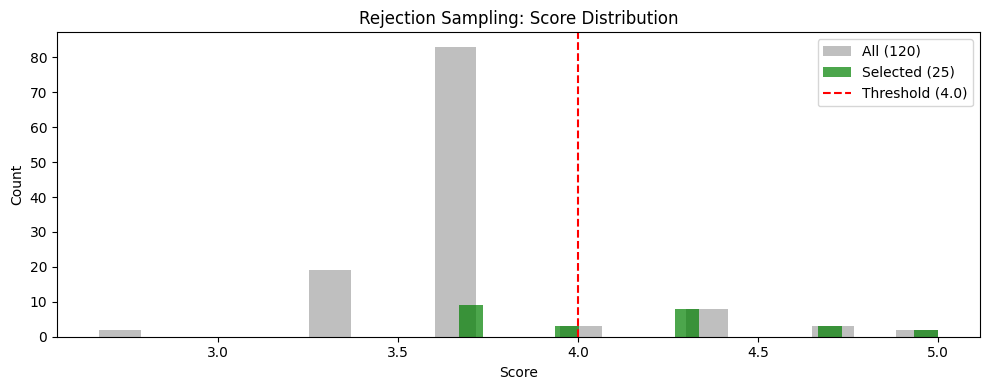

In [10]:
# 점수 분포 분석
print("📊 Score Distribution Analysis")
print("="*60)

all_scores = []
for candidate in scored_candidates:
    for resp in candidate["scored_responses"]:
        all_scores.append(resp["score"]["avg_score"])

selected_scores = [d["score"] for d in selected_data]
rejected_scores = [d["score"] for d in rejected_data]

# 히스토그램 (텍스트)
for label, scores in [("All", all_scores), ("Selected", selected_scores), ("Rejected(worst)", rejected_scores)]:
    print(f"\n🔹 {label} ({len(scores)} responses):")
    print(f"   Mean: {sum(scores)/len(scores):.2f} / Max: {max(scores):.1f} / Min: {min(scores):.1f}")
    
    for threshold in [5.0, 4.5, 4.0, 3.5, 3.0, 2.5, 2.0, 1.5, 1.0]:
        count = sum(1 for s in scores if s >= threshold and s < threshold + 0.5)
        bar = "█" * count
        if count > 0:
            print(f"   {threshold:.1f}~{threshold+0.4:.1f}: {bar} ({count})")

# matplotlib 시각화
try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    ax.hist(all_scores, bins=20, alpha=0.5, label=f"All ({len(all_scores)})", color="gray")
    ax.hist(selected_scores, bins=20, alpha=0.7, label=f"Selected ({len(selected_scores)})", color="green")
    ax.axvline(x=SCORE_THRESHOLD, color="red", linestyle="--", label=f"Threshold ({SCORE_THRESHOLD})")
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")
    ax.set_title("Rejection Sampling: Score Distribution")
    ax.legend()
    plt.tight_layout()
    plt.show()
except ImportError:
    print("ℹ️ matplotlib not installed")

## 5️⃣ 선택된 데이터로 SFT 학습

이제 Rejection Sampling으로 선별한 **고품질 데이터**로 모델을 학습합니다.

### 기대 효과
- 모델 자체에서 생성한 응답 → **분포가 자연스러움**
- 최고 품질만 선별 → **학습 효율 극대화**
- DPO처럼 복잡한 설정 없이 **일반 SFT로 가능**

In [ ]:
# 학습 전 응답 저장 (Before)
print("="*60)
print("📋 학습 전 모델 응답 (Before Training)")
print("="*60)

EVAL_PROMPTS = [
    "머신러닝과 딥러닝의 차이점을 설명하세요.",
    "트랜스포머 모델의 어텐션 메커니즘을 설명하세요.",
    "LoRA 파인튜닝의 장점을 설명하세요.",
    "LLM의 환각(Hallucination) 문제와 해결 방법을 설명하세요.",
]

def generate_eval_response(model, tokenizer, prompt):
    messages = [
        {"role": "system", "content": "당신은 유용한 AI 어시스턴트입니다."},
        {"role": "user", "content": prompt}
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        output = model.generate(
            **inputs, max_new_tokens=256, temperature=0.1,
            do_sample=True, pad_token_id=tokenizer.pad_token_id,
        )
    return tokenizer.decode(output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()

before_responses = []
for i, prompt in enumerate(EVAL_PROMPTS):
    resp = generate_eval_response(model, tokenizer, prompt)
    before_responses.append(resp)
    print(f"\n🔹 질문 {i+1}: {prompt}")
    print(f"   답변: {resp[:200]}...")


📋 학습 전 모델 응답 (Before Training)

🔹 질문 1: 오버피팅과 언더피팅의 차이를 설명하세요.
   답변: 오버피팅(Overshooting)과 언더피팅(Underfitting)은 머신러닝 모델에서 발생할 수 있는 두 가지 중요한 문제로, 각각 다른 특성을 가지고 있습니다.

1. 오버피팅: 
   - 이는 모델이 학습 데이터에 너무 잘 적응하여 일반화 성능이 떨어지는 현상을 말합니다.
   - 모델이 학습된 데이터와 비슷하거나 더 복잡한 데이터에서도 좋은 결과를...

🔹 질문 2: Transformer 모델에서 Self-Attention이 중요한 이유를 설명하세요.
   답변: Self-Attention은 Transformer 모델의 핵심 기능 중 하나로, 이는 문장 내부의 단어들 간에 상호 연관성을 파악하는 데 중요합니다. 

Transformer 모델은 주로 자연어 처리(NLP)와 같은 분야에서 사용되며, 이러한 작업에서는 각 단어가 다른 단어들과 어떻게 관련되어 있는지 이해해야 합니다. 이를 위해 Self-Attention을...

🔹 질문 3: 좋은 코드 리뷰를 하는 방법을 알려주세요.
   답변: 코드 리뷰는 개발자들이 코드의 효율성, 안전성, 품질 등을 평가하는 중요한 과정입니다. 다음은 코드 리뷰를 효과적으로 수행하기 위한 몇 가지 팁입니다:

1. **분명하고 명확한 요구사항**: 코드 리뷰 전에 개발자가 어떤 기능이나 성능을 달성해야 할지 명확하게 설명해야 합니다.

2. **필요한 정보 제공**: 코드 리뷰를 위해 필요한 모든 정보를 제공해...

🔹 질문 4: LLM 파인튜닝에서 LoRA를 사용하는 이유를 설명하세요.
   답변: LoRA (Low-Rank Adaptation)는 LLM (Large Language Model)의 파인튜닝 과정에서 주로 사용되는 방법 중 하나입니다. 이 방법을 통해 모델이 더 효율적으로 학습하고, 더 적은 데이터셋으로도 좋은 성능을 얻을 수 있습니다.

LoRA의 기본적인 원리는 다음과 같

In [12]:
# 학습 데이터 로드 또는 포맷팅
RS_DATA_PATH = os.path.join(OUTPUT_DIR, "rejection_sampling_data.json")

if os.path.exists(RS_DATA_PATH):
    # 이미 저장된 RS 데이터가 있으면 로드 (커널 재시작 시)
    print(f"💾 기존 RS 데이터 로드: {RS_DATA_PATH}")
    with open(RS_DATA_PATH, "r", encoding="utf-8") as f:
        rs_saved = json.load(f)
    selected_data = rs_saved["selected"]
    rejected_data = rs_saved["rejected"]
    print(f"   📄 선택된 데이터: {len(selected_data)}건")
    print(f"   📄 탈락 데이터: {len(rejected_data)}건")
else:
    print("📌 저장된 RS 데이터 없음 → 위 셀(2~4단계)에서 생성한 메모리 데이터 사용")

# Chat Template 포맷팅
def format_to_chat(sample):
    messages = [
        {"role": "system", "content": "당신은 유용한 AI 어시스턴트입니다. 정확하고 친절하게 답변해주세요."},
        {"role": "user", "content": sample["prompt"]},
        {"role": "assistant", "content": sample["response"]}
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
    return text

formatted_texts = [format_to_chat(s) for s in selected_data]
dataset = Dataset.from_dict({"text": formatted_texts})

print(f"✅ 학습 데이터 포맷팅 완료: {len(dataset)}개")
print(f"\n--- 포맷팅 예시 ---")
print(dataset[0]["text"][:300])

In [13]:
# LoRA 설정 및 적용
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
print_gpu_memory("LoRA 적용 후")


trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820
[LoRA 적용 후] GPU: 3.0GB / 23.5GB


In [14]:
# SFTTrainer 설정 및 학습
sft_config = SFTConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=5,            # 소량 데이터는 에폭을 높여야 학습 효과 나타남
    per_device_train_batch_size=1,
    gradient_accumulation_steps=1,  # 소량 데이터에서는 1로 설정 (step 수 확보)
    learning_rate=5e-4,            # 소량 데이터 + LoRA는 높은 lr로 빠르게 학습
    fp16=True,
    logging_steps=1,
    save_strategy="no",
    max_length=1024,
    gradient_checkpointing=True,
    dataset_text_field="text",
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=dataset,
    processing_class=tokenizer,
)

print("✅ SFTTrainer 초기화 완료")
print(f"📌 데이터: {len(dataset)}건")
print(f"📌 epochs: {sft_config.num_train_epochs}")
print(f"📌 gradient_accumulation: {sft_config.gradient_accumulation_steps}")
print(f"📌 예상 총 step: {len(dataset) * sft_config.num_train_epochs}")
print(f"📌 learning_rate: {sft_config.learning_rate}")
print_gpu_memory("학습 시작 전")

/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
Truncating train dataset: 100%|██████████| 25/25 [00:00<00:00, 8854.72 examples/s]
The model is already on multiple devices. Skipping the move to device specified in `args`.


✅ SFTTrainer 초기화 완료
📌 데이터: 25건
📌 epochs: 5
📌 gradient_accumulation: 1
📌 예상 총 step: 125
📌 learning_rate: 0.0005
[학습 시작 전] GPU: 3.0GB / 23.5GB


In [15]:
# 학습 실행
print("🚀 Rejection Sampling SFT 학습 시작!")
print("="*60)

start_time = time.time()
train_result = trainer.train()
training_time = time.time() - start_time

print("="*60)
print("✅ 학습 완료!")
print(f"📌 Total steps: {train_result.global_step}")
print(f"📌 Training loss: {train_result.training_loss:.4f}")
print(f"📌 학습 시간: {training_time:.1f}초")
print_gpu_memory("학습 완료 후")


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


🚀 Rejection Sampling SFT 학습 시작!


Step,Training Loss
1,1.408100
2,1.213400
3,1.159300
4,0.660400
5,0.885900
6,0.919900
7,1.167200
8,1.284800
9,0.579900
10,0.993000


✅ 학습 완료!
📌 Total steps: 125
📌 Training loss: 0.3889
📌 학습 시간: 43.0초
[학습 완료 후] GPU: 3.1GB / 23.5GB


## 6️⃣ 학습 전후 비교

Rejection Sampling으로 선별한 고품질 데이터로 학습한 결과를 확인합니다.

In [16]:
# 학습 후 응답 생성 및 비교
print("="*60)
print("📊 학습 전후 비교 (Before vs After)")
print("="*60)

model.eval()
# dtype 불일치 방지 (LoRA 학습 후 float32 어댑터 → float16 변환)
for name, param in model.named_parameters():
    if param.dtype == torch.float32:
        param.data = param.data.to(torch.float16)

after_responses = []

for i, prompt in enumerate(EVAL_PROMPTS):
    resp = generate_eval_response(model, tokenizer, prompt)
    after_responses.append(resp)
    
    print(f"\n{'='*60}")
    print(f"🔹 질문 {i+1}: {prompt}")
    print(f"\n📌 Before:")
    print(f"   {before_responses[i][:250]}")
    print(f"\n📌 After (RS+SFT):")
    print(f"   {resp[:250]}")

📊 학습 전후 비교 (Before vs After)

🔹 질문 1: 오버피팅과 언더피팅의 차이를 설명하세요.

📌 Before:
   오버피팅(Overshooting)과 언더피팅(Underfitting)은 머신러닝 모델에서 발생할 수 있는 두 가지 중요한 문제로, 각각 다른 특성을 가지고 있습니다.

1. 오버피팅: 
   - 이는 모델이 학습 데이터에 너무 잘 적응하여 일반화 성능이 떨어지는 현상을 말합니다.
   - 모델이 학습된 데이터와 비슷하거나 더 복잡한 데이터에서도 좋은 결과를 내는 경우가 많습니다.
   - 예측력이 너무 좋게 보일 수 있지만, 실제 신뢰도가 낮아

📌 After (RS+SFT):
   오버피팅(Overfitting)과 언더피팅(Underfitting)은 학습 모델에서 주로 사용되는 두 가지 개념으로,它们分别描述了模型在训练数据和测试数据上的表现。

1. **오버피팅**: 이는 학습 데이터에过分拟合的现象를 나타내ます. 즉, 모델이 너무 잘 특정 데이터셋을 예측하는 것으로 간주될 수 있습니다. 이러한 경우, 모델이 더 많은 학습 데이터나 시도를 통해 더욱 좋게 작동하게 될 것이라는 가정하에 만들어진 것이므로, 일반적으로 복잡하고 큰

🔹 질문 2: Transformer 모델에서 Self-Attention이 중요한 이유를 설명하세요.

📌 Before:
   Self-Attention은 Transformer 모델의 핵심 기능 중 하나로, 이는 문장 내부의 단어들 간에 상호 연관성을 파악하는 데 중요합니다. 

Transformer 모델은 주로 자연어 처리(NLP)와 같은 분야에서 사용되며, 이러한 작업에서는 각 단어가 다른 단어들과 어떻게 관련되어 있는지 이해해야 합니다. 이를 위해 Self-Attention을 사용하여 각 단어가 다른 단어들에 대해 어떤 역할을 하는지를 결정합니다.

예를 들어, 

📌 After (RS+SFT):
   Self-Attention는 Transformers에서 매우 중요하며, 이는 복잡한 문장 분석과 생성 

In [17]:
# LLM Judge로 Before/After 정량 비교
print("\n" + "="*60)
print("📊 LLM Judge 정량 비교 (Before vs After)")
print("="*60)

before_scores = []
after_scores = []

for i, prompt in enumerate(EVAL_PROMPTS):
    b_score = score_response(prompt, before_responses[i])
    a_score = score_response(prompt, after_responses[i])
    before_scores.append(b_score["avg_score"])
    after_scores.append(a_score["avg_score"])
    
    diff = a_score["avg_score"] - b_score["avg_score"]
    emoji = "📈" if diff > 0 else ("📉" if diff < 0 else "➡️")
    print(f"\n{emoji} 질문 {i+1}: {prompt[:40]}...")
    print(f"   Before: {b_score['avg_score']:.1f}점 / After: {a_score['avg_score']:.1f}점 ({diff:+.1f})")

print(f"\n{'='*60}")
print(f"📊 평균 점수:")
print(f"   Before: {sum(before_scores)/len(before_scores):.2f}")
print(f"   After:  {sum(after_scores)/len(after_scores):.2f}")
print(f"   변화:   {sum(after_scores)/len(after_scores) - sum(before_scores)/len(before_scores):+.2f}")



📊 LLM Judge 정량 비교 (Before vs After)

📉 질문 1: 오버피팅과 언더피팅의 차이를 설명하세요....
   Before: 3.7점 / After: 3.3점 (-0.3)

📉 질문 2: Transformer 모델에서 Self-Attention이 중요한 이유를...
   Before: 4.7점 / After: 3.3점 (-1.3)

📉 질문 3: 좋은 코드 리뷰를 하는 방법을 알려주세요....
   Before: 4.7점 / After: 4.0점 (-0.7)

📉 질문 4: LLM 파인튜닝에서 LoRA를 사용하는 이유를 설명하세요....
   Before: 3.7점 / After: 3.3점 (-0.3)

📊 평균 점수:
   Before: 4.17
   After:  3.50
   변화:   -0.67


## 7️⃣ 모델 저장 및 데이터 저장

In [18]:
# Rejection Sampling 데이터 저장 (커널 재시작 후에도 재사용 가능)
os.makedirs(OUTPUT_DIR, exist_ok=True)

rs_data_path = os.path.join(OUTPUT_DIR, "rejection_sampling_data.json")
with open(rs_data_path, "w", encoding="utf-8") as f:
    json.dump({
        "selected": selected_data,
        "rejected": rejected_data,
        "metadata": {
            "model": MODEL_NAME,
            "total_selected": len(selected_data),
        }
    }, f, ensure_ascii=False, indent=2)
print(f"✅ RS 데이터 저장: {rs_data_path}")

# LoRA 어댑터 저장
save_path = os.path.join(OUTPUT_DIR, "lora_adapter")
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f"✅ 어댑터 저장 완료: {save_path}")

# 저장 크기 확인
total_size = sum(
    os.path.getsize(os.path.join(dp, f))
    for dp, dn, fns in os.walk(save_path)
    for f in fns
)
print(f"📌 어댑터 크기: {total_size / 1024 / 1024:.1f} MB")

In [19]:
# GPU 메모리 정리
del model, trainer
gc.collect()
torch.cuda.empty_cache()
print_gpu_memory("정리 후")


[정리 후] GPU: 0.0GB / 23.5GB


## 📝 정리 및 핵심 요약

### 이번 실습에서 배운 내용

```
프롬프트 15개
    ↓ N=8 응답 생성 (temperature=0.8)
총 120개 응답
    ↓ LLM Judge (GPT-4o-mini) 평가
점수 매긴 120개 응답
    ↓ Best-of-N + Threshold(4.0) 선택
고품질 SFT 데이터
    ↓ LoRA SFT 학습
성능 향상된 모델!
```

### 핵심 포인트

- 🎯 **Rejection Sampling = 자가 증류(Self-Distillation)**: 모델 자체 출력에서 최고를 골라 다시 학습
- 🎯 **DPO/PPO 없이도 성능 향상 가능**: 일반 SFT만으로 고품질 데이터 효과를 누림
- 🎯 **N이 클수록 좋은 응답 확률 ↑**: 하지만 생성 비용도 N배 (trade-off)
- 🎯 **LLM Judge 비용 저렴**: GPT-4o-mini로 120개 평가 ~$0.12
- 🎯 **DeepSeek R1 파이프라인의 핵심 단계**: Cold Start → GRPO → **RS + SFT** → GRPO → Final

### Rejection Sampling vs 다른 방법

| 방법 | 데이터 | 복잡도 | 효과 |
|------|--------|--------|------|
| 일반 SFT | 외부 데이터 | ⭐ | 기본 |
| **RS + SFT** | **자체 생성 + 선별** | ⭐⭐ | **좋음** |
| DPO | chosen/rejected 쌍 | ⭐⭐⭐ | 매우 좋음 |
| PPO/GRPO | 보상 모델 필요 | ⭐⭐⭐⭐ | 최고 |

### 실무 팁
- 프롬프트 다양성이 중요 (최소 100개 이상 권장)
- N=8~16이 가성비 최적
- Threshold는 데이터 분포 보고 조절 (너무 높으면 데이터 부족)
- RS 데이터 + 기존 SFT 데이터 혼합 학습도 효과적

### 다음 단계
- **Session 27**: DPO 학습 — RS+SFT 위에 선호도 정렬을 추가하면 더 강력!
- RS로 만든 데이터를 DPO의 chosen으로 활용 가능